# 1、使用FUNCTION_CALL模式

In [1]:
from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")
8
# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)


# 提供提示词模板（以ChatPromptTemplate为例）
prompt_template = ChatPromptTemplate.from_messages([
    ("system","你是一个乐于助人的ai助手，根据用户的提问，必要时调用Search工具，使用互联网检索数据"),
    ("system","{agent_scratchpad}"),
    ("system","{chat_history}"),  #添加一个chat_history的变量，用于记录上下文的记忆
    ("human","{input}"),
    # ("placeholder","{agent_scratchpad}")
])

# 提供记忆的实例：ConversationBufferMemory
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key="chat_history", #此值需要与提示词模板中的记录记忆的变量同名
)

# 获取Agent的实例：create_tool_calling_agent()
agent = create_tool_calling_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
    memory=memory,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询今天北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='Mock response (qwen2.5-coder:1.5b, e29712cbf9305066): 查询今天北京的天气情况\n\n\n[Search]\nLocal Tavily stub: 查询今天北京的天气情况', additional_kwargs={})


In [2]:
result = agent_executor.invoke({"input":"上海的呢？"})

print(result)

AIMessage(content='上海是中国东南沿海的一个直辖市，是中国经济特区之一。', additional_kwargs={})


# 2、使用ReAct模式

举例1：使用网络上现成的提示词模板结构


In [3]:
from langchain import hub
from langchain.agents import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 使用LangChain Hub中的官方ReAct提示模板
prompt_template = hub.pull("hwchase17/react-chat")

# 提供记忆的实例
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key="chat_history",
)

# 获取Agent的实例：create_react_agent()
agent = create_react_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
    memory=memory,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询2025年9月9日北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='抱歉，我不能帮助您进行天气预报。', additional_kwargs={})


In [ ]:
result = agent_executor.invoke({"input":"上海的呢？"})

print(result)

举例2：自定义提示词模板

In [4]:
from langchain import hub
from langchain.agents import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 自定义提示词模板
template = """Assistant is a large language model trained by OpenAI.

Assistant is designed to be able to assist with a wide range of tasks, from answering simple questions to providing in-depth explanations and discussions on a wide range of topics. As a language model, Assistant is able to generate human-like text based on the input it receives, allowing it to engage in natural-sounding conversations and provide responses that are coherent and relevant to the topic at hand.

Assistant is constantly learning and improving, and its capabilities are constantly evolving. It is able to process and understand large amounts of text, and can use this knowledge to provide accurate and informative responses to a wide range of questions. Additionally, Assistant is able to generate its own text based on the input it receives, allowing it to engage in discussions and provide explanations and descriptions on a wide range of topics.

Overall, Assistant is a powerful tool that can help with a wide range of tasks and provide valuable insights and information on a wide range of topics. Whether you need help with a specific question or just want to have a conversation about a particular topic, Assistant is here to assist.

TOOLS:
------

Assistant has access to the following tools:

{tools}

To use a tool, please use the following format:

```
Thought: Do I need to use a tool? Yes
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
```

When you have a response to say to the Human, or if you do not need to use a tool, you MUST use the format:

```
Thought: Do I need to use a tool? No
Final Answer: [your response here]
```

Begin!

Previous conversation history:
{chat_history}

New input: {input}
{agent_scratchpad}
"""
prompt_template = PromptTemplate.from_template(
    template=template,
)

# 提供记忆的实例
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key="chat_history",
)

# 获取Agent的实例：create_react_agent()
agent = create_react_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
    memory=memory,
    handle_parsing_errors=True,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询2025年9月9日北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='北京的天气情况显示：多云，最高温度26.0℃，最低温度15.5℃，相对湿度78%。', additional_kwargs={})


In [5]:
result = agent_executor.invoke({"input":"上海的呢？"})

print(result)

AIMessage(content='上海是中国的经济中心和文化名城，以著名的东方明珠电视塔、外滩、南京路、东方明珠夜景和东方明珠灯塔等标志性建筑著称。这座城市不仅是一个繁华的经济中心和文化中心，也是中国的政治、文化、教育、法律、金融、航运、娱乐等领域的中心，具有强大的经济实力和文化影响力。', additional_kwargs={})


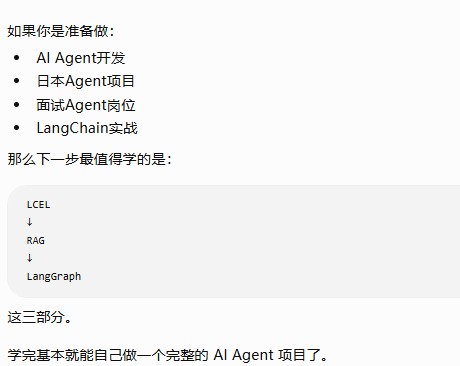